# 📉 Customer Churn Prediction
> **Goal:** Predict which customers are likely to leave a telecom company, and understand *why* to enable proactive retention strategies.

**Dataset:** [Telco Customer Churn — Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)  
**Author:** Yasmine Pérez  
**Stack:** Python · Pandas · Scikit-learn · XGBoost · SHAP · Matplotlib · Seaborn

---
## 📋 Table of Contents
1. [Setup & Data Loading](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Preprocessing & Feature Engineering](#3)
4. [Modeling: Logistic Regression, Random Forest, XGBoost](#4)
5. [Evaluation & Threshold Optimization](#5)
6. [Model Interpretability with SHAP](#6)
7. [Business Insights & Recommendations](#7)

---
<a id='1'></a>
## 1. Setup & Data Loading

In [32]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score
)

# Interpretability
import shap

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [33]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]:.1%}')
df.head()

Shape: (7043, 21)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Insight:** Imbalanced class of 26.5% churn

---
<a id='2'></a>
## 2. Exploratory Data Analysis (EDA)

In [34]:
# Basic overview
print('=== Data Types ===') # columns
print(df.dtypes.value_counts())
print('\n=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Target Distribution ===')
print(df['Churn'].value_counts())

=== Data Types ===
object     18
int64       2
float64     1
Name: count, dtype: int64

=== Missing Values ===
Series([], dtype: int64)

=== Target Distribution ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64


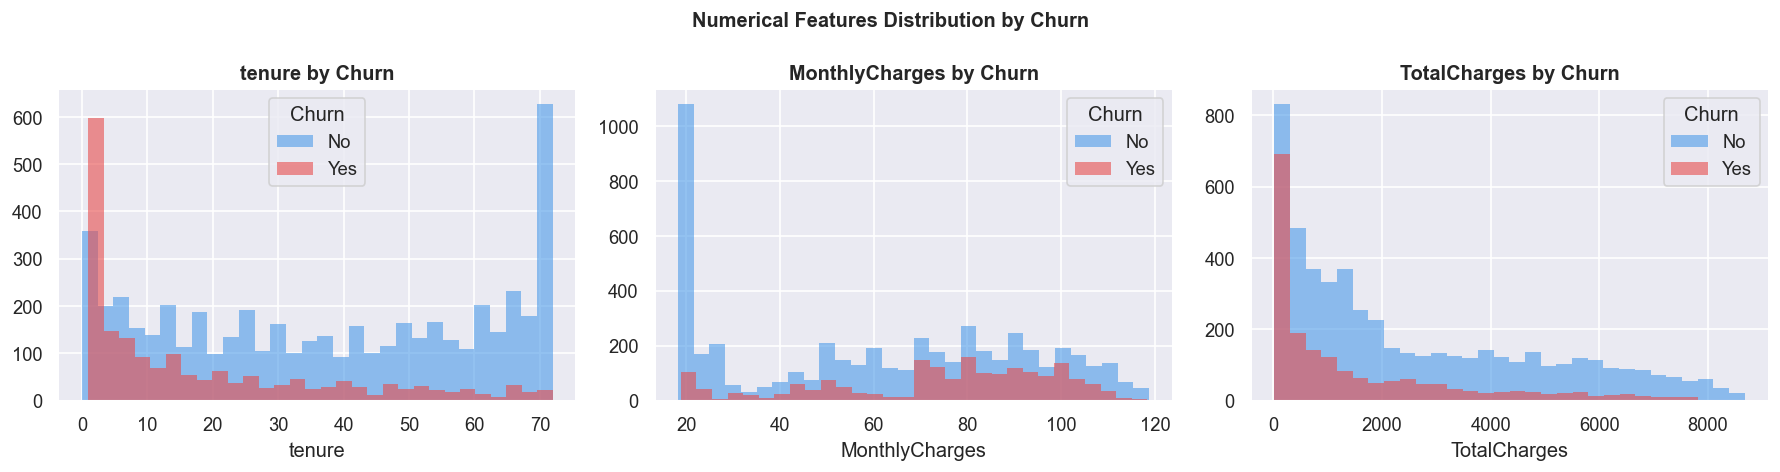

In [36]:
# Numerical features distribution by churn
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Transform TotalCharges 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for label, color in zip(['No', 'Yes'], ['#4C9BE8', '#E84C4C']):
        subset = df[df['Churn'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='none')
    ax.set_title(f'{col} by Churn', fontweight='bold')
    ax.legend(title='Churn')
    ax.set_xlabel(col)

plt.suptitle('Numerical Features Distribution by Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('img/numerical_distributions.png', bbox_inches='tight')
plt.show()

**Conclusion:**
- Customers with shorter tenure are significantly more likely to churn.
- Higher monthly charges are associated with greater churn risk.
- Low total charges reinforce the pattern that churn is concentrated among newer customers.
- Overall, early-stage customers paying relatively more per month appear to be the most at risk.

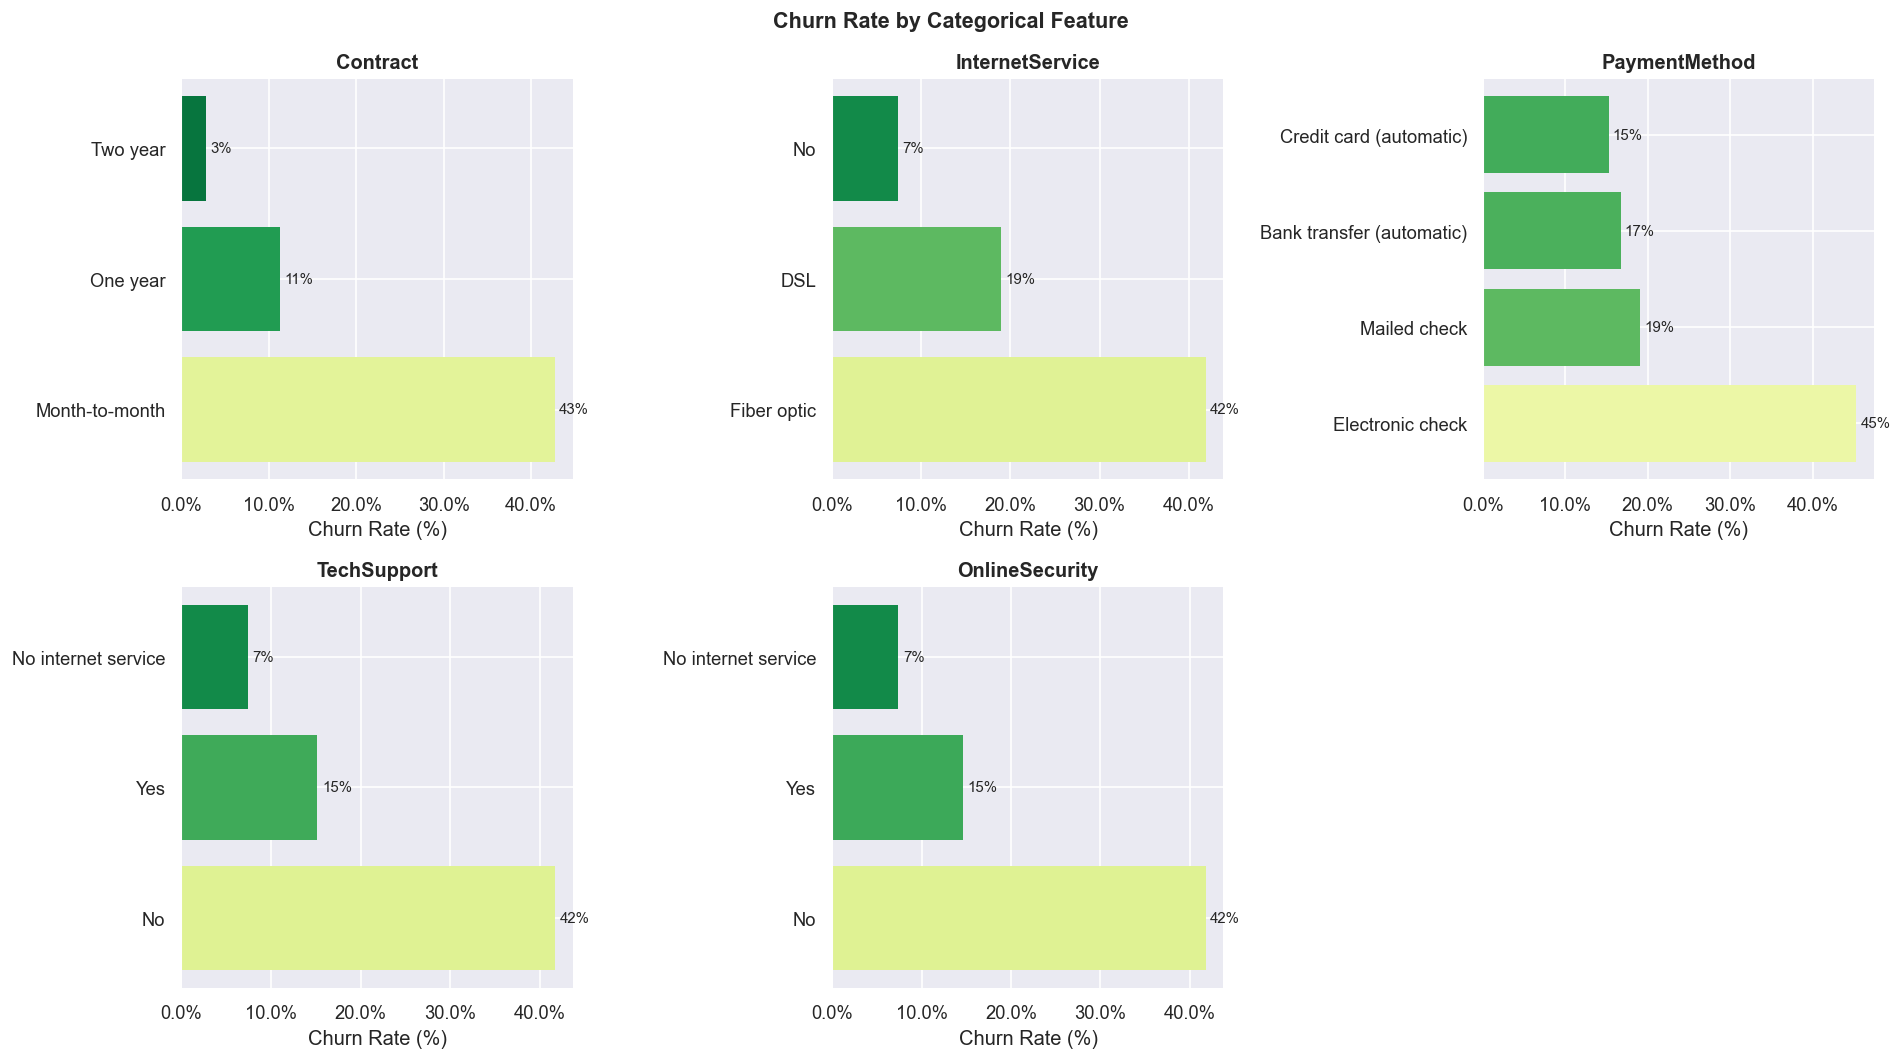

In [37]:
# Categorical features: churn rate per category
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    bars = ax.barh(churn_rate.index, churn_rate.values * 100,
                   color=plt.cm.RdYlGn_r(churn_rate.values), edgecolor='none')
    ax.set_xlabel('Churn Rate (%)')
    ax.set_title(col, fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, churn_rate.values):
        ax.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.0%}', va='center', fontsize=9)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('img/categorical_churn_rates.png', bbox_inches='tight')
plt.show()

**Conclusion:**
- Month-to-month contracts are strongly associated with churn, while longer contracts are linked to retention.
- Fiber optic customers show the highest churn rate among internet service groups.
- Electronic check users churn more than customers using automatic payment methods.
- Customers without TechSupport or OnlineSecurity are significantly more likely to churn.
- The riskiest segment combines flexible contracts, premium internet service, and low adoption of support/security add-ons.

---
<a id='3'></a>
## 3. Preprocessing & Feature Engineering

In [ ]:
# --- Clean & Encode ---
df_model = df.copy()

# Drop customerID
df_model.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges
df_model['TotalCharges'] = pd.to_numeric(df_model['TotalCharges'], errors='coerce')
df_model['TotalCharges'].fillna(df_model['TotalCharges'].median(), inplace=True)

# Target encode (Churn: Yes=1, No=0)
df_model['Churn'] = (df_model['Churn'] == 'Yes').astype(int)

# Feature engineering
# AvgMonthlySpend is the average amount a customer spends per month.
df_model['AvgMonthlySpend'] = df_model['TotalCharges'] / (df_model['tenure'] + 1)
# IsNewCustomer flags those in their first 6 months, who are more likely to churn.
df_model['IsNewCustomer'] = (df_model['tenure'] <= 6).astype(int)
# HasMultipleServices counts how many of the key services a customer has, as more services can increase stickiness.
df_model['HasMultipleServices'] = (
    (df_model['OnlineSecurity'] == 'Yes').astype(int) +
    (df_model['TechSupport'] == 'Yes').astype(int) +
    (df_model['StreamingTV'] == 'Yes').astype(int) +
    (df_model['StreamingMovies'] == 'Yes').astype(int)
)

# Separate features
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Categorical features ({len(cat_features)}): {cat_features}')
print(f'Numerical features ({len(num_features)}): {num_features}')
print(f'\nTarget balance: {y.value_counts(normalize=True).round(3).to_dict()}')

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical features (7): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'IsNewCustomer', 'HasMultipleServices']

Target balance: {0: 0.735, 1: 0.265}


In [39]:
# Preprocessing pipeline transforming numerical features with StandardScaler and categorical features with OneHotEncoder
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.2%} | Test churn rate: {y_test.mean():.2%}')

Train: (5634, 22) | Test: (1409, 22)
Train churn rate: 26.54% | Test churn rate: 26.54%


---
<a id='4'></a>
## 4. Modeling: Logistic Regression, Random Forest, XGBoost

In [40]:
# Define models to compare results with cross-validation
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=3, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42, verbosity=0)
}

# Cross-validation with StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

for name, model in models.items():
    scores = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='roc_auc')
    results[name] = scores
    print(f'{name:25} | AUC-ROC: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       | AUC-ROC: 0.8486 ± 0.0113
Random Forest             | AUC-ROC: 0.8261 ± 0.0118
XGBoost                   | AUC-ROC: 0.8229 ± 0.0082


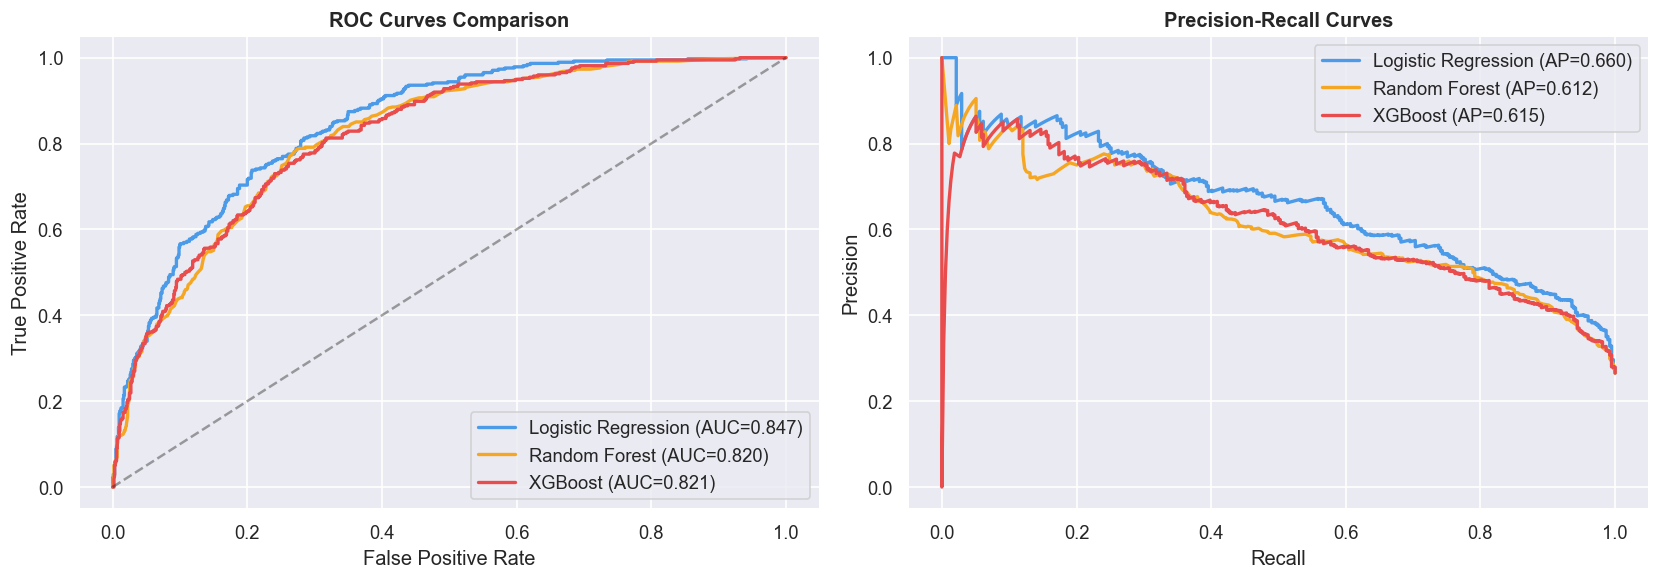

In [41]:
# Fit all models on full train set
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    fitted_models[name] = model

# ROC curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C9BE8', '#F5A623', '#E84C4C']
for (name, model), color in zip(fitted_models.items(), colors):
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves Comparison', fontweight='bold')
axes[0].legend()

# Precision-Recall curves
for (name, model), color in zip(fitted_models.items(), colors):
    y_proba = model.predict_proba(X_test_proc)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=color, lw=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('img/roc_pr_curves.png', bbox_inches='tight')
plt.show()

**Conclusion:**
- Logistic Regression achieved the best overall discrimination performance, with the highest ROC-AUC (0.847) and the highest Average Precision (0.660) among the three models.
- It provides better class separation than Random Forest and XGBoost while also being simpler, more stable, and easier to interpret.
- Given its stronger predictive performance and higher interpretability, it is the most suitable model for this churn prediction task.

---
<a id='5'></a>
## 5. Evaluation & Threshold Optimization

> 💡 **Business context:** Missing a churner (FN) is more costly than a false alarm (FP).  
> We optimize the threshold to **maximize F2-score** (weights Recall more than Precision).

Optimal threshold (F2): 0.58


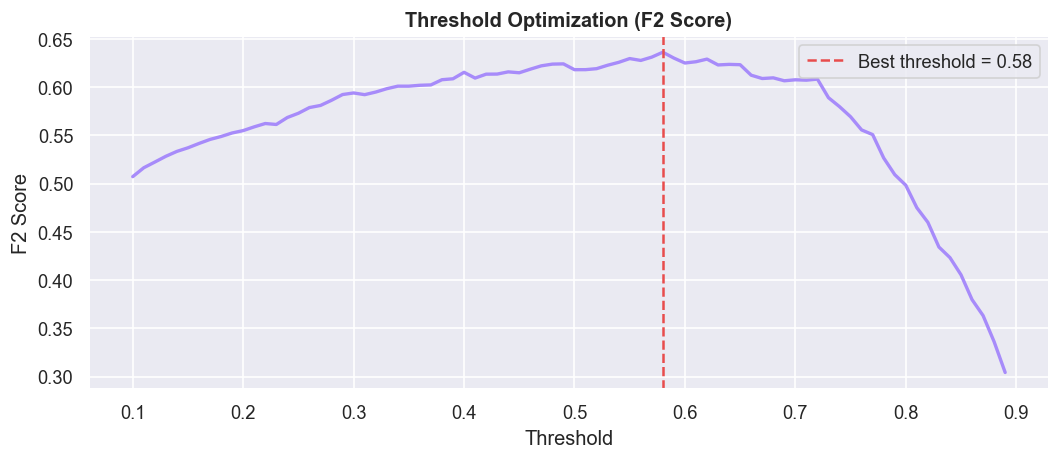

In [42]:
# Use XGBoost as final model (best AUC)
best_model = fitted_models['Logistic Regression']
y_proba = best_model.predict_proba(X_test_proc)[:, 1]

# Find threshold that maximizes F2 score instead of default 0.5, since we want to prioritize recall (catching churners) over precision.
thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f2 = f1_score(y_test, y_pred_t, zero_division=0)
    f2_scores.append(f2)

best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Optimal threshold (F2): {best_threshold:.2f}')

# Final predictions
y_pred_final = (y_proba >= best_threshold).astype(int)

# Threshold plot
plt.figure(figsize=(9, 4))
plt.plot(thresholds, f2_scores, color='#A78BFA', lw=2)
plt.axvline(best_threshold, color='#E84C4C', linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.title('Threshold Optimization (F2 Score)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('img/threshold_optimization.png', bbox_inches='tight')
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.56      0.74      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.78      1409



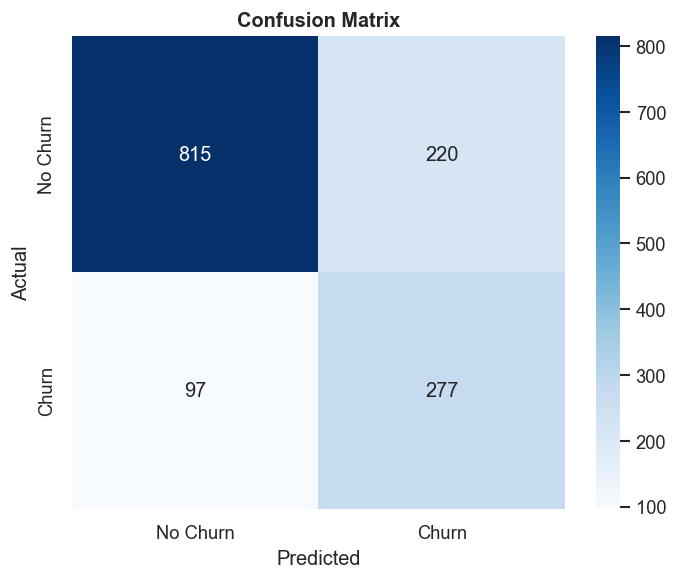

In [43]:
# Classification report & Confusion Matrix
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_final, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('img/confusion_matrix.png', bbox_inches='tight')
plt.show()

**Conclusions:**
- Detecta bien los clientes que se van.
- Aunque también detecta varios falsos positivos (271).
- Pocos FN lo que importa al negocio.

---
<a id='6'></a>
## 6. Model Interpretability with SHAP

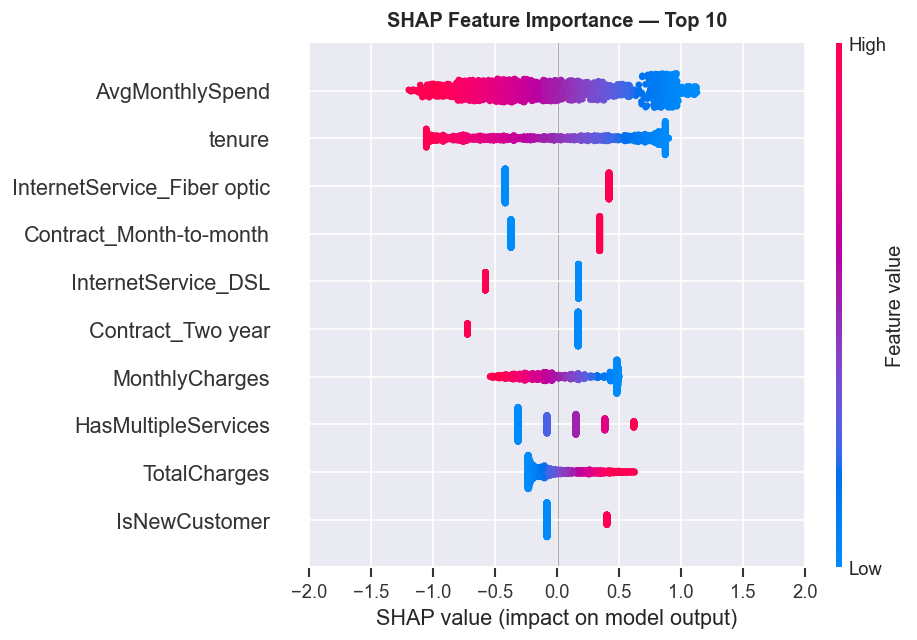

In [51]:
# SHAP values
explainer = shap.LinearExplainer(best_model, X_train_proc)
shap_values = explainer.shap_values(X_test_proc)

# Get feature names after one-hot encoding
ohe_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_features)
all_features = num_features + list(ohe_features)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_proc, feature_names=all_features,
                  max_display=10, show=False)
plt.xlim(-2,2)
plt.title('SHAP Feature Importance — Top 10', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('img/shap_summary.png', bbox_inches='tight')
plt.show()

**Insights:**
- SHAP confirms that churn is primarily explained by customer maturity, contract structure, and service-price profile.
- Newer customers, especially those on month-to-month contracts and fiber optic plans, are more likely to churn.
- Longer tenure and long-term contracts act as strong protective factors.
- These results reinforce the business case for focusing retention efforts on early-stage customers with flexible contracts and relatively expensive plans.

---
<a id='7'></a>
## 7. Business Insights & Recommendations

Based on EDA and SHAP analysis, the most actionable churn drivers are:

| Driver | Insight | Recommended Action |
|---|---|---|
| **Contract type** | Month-to-month customers have by far the highest churn rate compared with one- and two-year contracts | Offer migration incentives to move high-risk customers to longer-term plans |
| **Tenure** | The first 6 months are the most critical stage of the customer lifecycle | Launch an early onboarding and retention program with proactive check-in calls |
| **Monthly charges** | Higher monthly charges are associated with greater churn risk | Test bundle discounts, loyalty credits, or plan-rightsizing for high-bill customers |
| **Tech Support / Security** | Customers without TechSupport or OnlineSecurity churn substantially more | Offer targeted free trials or attach support/security benefits to vulnerable segments |
| **Payment method** | Electronic check customers show the highest churn rate | Incentivize auto-pay or card-based payment migration |
| **Internet service** | Fiber optic customers show higher churn than DSL customers | Review pricing, service expectations, and retention offers for fiber customers |

In [56]:
# Final model summary
print('=' * 55)
print('        FINAL MODEL SUMMARY — Logistic Regression')
print('=' * 55)
print(f'  AUC-ROC:          {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Optimal threshold: {best_threshold:.2f}')
print(f'  Recall (Churn):   {(y_pred_final[y_test==1]==1).mean():.4f}')
print(f'  Precision (Churn):{(y_test[y_pred_final==1]==1).mean():.4f}')
print('=' * 55)

        FINAL MODEL SUMMARY — Logistic Regression
  AUC-ROC:          0.8472
  Optimal threshold: 0.58
  Recall (Churn):   0.7406
  Precision (Churn):0.5573
